# Revolut case study

### Import packages

In [1]:
import numpy as np
import pandas as pd
import ast # for converting data to dict

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

import seaborn as sns

C:\Users\pitla\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Import files
doc_report = pd.read_csv('doc_report.csv', )
facial_report = pd.read_csv('facial_similarity_report.csv')

## Exploratory data analysis

### Explore document report

In [3]:
# View the data 
doc_report.head()

,number,user_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties,sub_result
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,consider,consider,clear,clear,clear,2017-06-20T23:12:57Z,clear,NaN,NaN,clear,clear,NaN,050a0596de424fab83c433eaa18b3f8d,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,clear,clear,clear,2017-06-20T23:16:04Z,clear,NaN,NaN,clear,NaN,NaN,f69c1e5f45a64e50a26740b9bfb978b7,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,clear,clear,clear,2017-06-20T17:59:49Z,clear,NaN,NaN,clear,clear,NaN,f9f84f3055714d8e8f7419dc984d1769,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,clear,clear,clear,2017-06-20T17:59:38Z,clear,NaN,NaN,clear,clear,NaN,10a54a1ecf794404be959e030f11fef6,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,clear,clear,clear,2017-06-20T18:08:09Z,clear,NaN,NaN,clear,clear,NaN,1f320d1d07de493292b7e0d5ebfb1cb9,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear


### Initial findings: 
- created_date column containing timestamp 
- attempt_id in the middle of the table 
- properties column containing dict like data

In [4]:
# Gathering info on the dataset 
doc_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   number                              176404 non-null  int64 
 1   user_id                             176404 non-null  object
 2   result                              176404 non-null  object
 3   visual_authenticity_result          150290 non-null  object
 4   image_integrity_result              176403 non-null  object
 5   face_detection_result               150261 non-null  object
 6   image_quality_result                176403 non-null  object
 7   created_at                          176404 non-null  object
 8   supported_document_result           175900 non-null  object
 9   conclusive_document_quality_result  95217 non-null   object
 10  colour_picture_result               95222 non-null   object
 11  data_validation_result              142

In [5]:
# Avoid issues with large numeric IDs 
doc_report['user_id'] = doc_report['user_id'].astype(str)
doc_report['attempt_id'] = doc_report['attempt_id'].astype(str)

In [6]:
# Convert created_at to date 
doc_report['created_at'] = pd.to_datetime(doc_report['created_at'])

In [7]:
# Create a creation date column
doc_report['created_date'] = doc_report['created_at'].dt.date

In [ ]:
# Fill NaN with 

### Place ID columns at the beginning

In [8]:
# Move attempt ID to the front of the DF
cols = ['number','user_id','attempt_id'] + [col for col in doc_report.columns if col not in ['number','user_id','attempt_id']]
doc_report = doc_report[cols]

In [9]:
doc_report

,number,user_id,attempt_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,properties,sub_result,created_date
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,consider,consider,clear,clear,clear,2017-06-20 23:12:57+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution,2017-06-20
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,clear,clear,clear,2017-06-20 23:16:04+00:00,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear,2017-06-20
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,clear,clear,clear,2017-06-20 17:59:49+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear,2017-06-20
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,clear,clear,clear,2017-06-20 17:59:38+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear,2017-06-20
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,clear,clear,clear,2017-06-20 18:08:09+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear,2017-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,clear,clear,clear,2017-06-20 22:25:53+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Female', 'nationality': 'CHN', 'do...",clear,2017-06-20
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,clear,clear,clear,2017-06-20 22:27:40+00:00,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear,2017-06-20
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,clear,clear,clear,2017-06-20 22:25:59+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Female', 'nationality': 'GBR', 'do...",clear,2017-06-20
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,clear,clear,clear,2017-06-20 22:35:40+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'PRT', 'docu...",clear,2017-06-20


In [ ]:
#doc_report = doc_report.drop('properties_v2', axis=1)

### Extract doc check report properties

In [10]:
# Check data type of properties column 
doc_report['properties'].apply(type)

0         <class 'str'>
1         <class 'str'>
2         <class 'str'>
3         <class 'str'>
4         <class 'str'>
              ...      
176399    <class 'str'>
176400    <class 'str'>
176401    <class 'str'>
176402    <class 'str'>
176403    <class 'str'>
Name: properties, Length: 176404, dtype: object

In [11]:
# Handling strings that look like dicts
doc_report['properties'] = doc_report['properties'].apply(ast.literal_eval)

In [12]:
# Set the dtype explicitly for any empty entries before applying .apply(pd.Series) to avoid warning message
doc_report['properties'] = doc_report['properties'].apply(lambda x: x if isinstance(x, dict) else {})

# Flatten the dict column
doc_expanded = doc_report['properties'].apply(pd.Series)

In [13]:
# View flattened data
doc_expanded

,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
176399,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [14]:
# Add user and attempt IDs to the dataset 
doc_expanded[['user_id','attempt_id']] = doc_report[['user_id','attempt_id']]

# Move ID columns to the front
cols = ['user_id','attempt_id'] + [col for col in doc_expanded.columns if col not in ['user_id','attempt_id']]
doc_expanded = doc_expanded[cols]

In [15]:
# See the dataset
doc_expanded

,user_id,attempt_id,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
176399,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [ ]:
# Nationality vs. issuing country


# Missing values
#print(doc_expanded.isnull().sum())

In [16]:
# Missing values
#print(doc_report.isnull().sum())

number                                     0
user_id                                    0
attempt_id                                 0
result                                     0
visual_authenticity_result             26114
image_integrity_result                     1
face_detection_result                  26143
image_quality_result                       1
created_at                                 0
supported_document_result                504
conclusive_document_quality_result     81187
colour_picture_result                  81182
data_validation_result                 33430
data_consistency_result                84175
data_comparison_result                173856
police_record_result                   31847
compromised_document_result           130898
properties                                 0
sub_result                                 0
created_date                               0
dtype: int64


In [ ]:
# Categorical column check: result
#doc_report.value_counts('result')

### Explore facial similarity report

In [18]:
# View first few rows of the dataset
facial_report.head()

,number,user_id,result,face_comparison_result,created_at,facial_image_integrity_result,visual_authenticity_result,properties,attempt_id
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,clear,clear,2017-06-20T23:12:58Z,clear,consider,{},050a0596de424fab83c433eaa18b3f8d
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,2017-06-20T23:16:04Z,clear,clear,{},f69c1e5f45a64e50a26740b9bfb978b7
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,2017-06-20T17:59:49Z,clear,clear,{},f9f84f3055714d8e8f7419dc984d1769
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,2017-06-20T17:59:39Z,clear,clear,{},10a54a1ecf794404be959e030f11fef6
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,2017-06-20T18:08:09Z,clear,clear,{},1f320d1d07de493292b7e0d5ebfb1cb9


In [19]:
# Reorder columns to have IDs in the first two columns

# Get columns names 
cols = list(facial_report.columns)

# Move last column to second position
last_col = cols[-1]
new_order = [cols[0],cols[1],last_col] + cols[2:-1]

# Reorder the DF
facial_report = facial_report[new_order]

In [20]:
# Get a summary of the DataFrame (structure, data types, missing values)
facial_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   number                         176404 non-null  int64 
 1   user_id                        176404 non-null  object
 2   attempt_id                     176404 non-null  object
 3   result                         176403 non-null  object
 4   face_comparison_result         166007 non-null  object
 5   created_at                     176404 non-null  object
 6   facial_image_integrity_result  175941 non-null  object
 7   visual_authenticity_result     150290 non-null  object
 8   properties                     176404 non-null  object
dtypes: int64(1), object(8)
memory usage: 12.1+ MB


In [21]:
# Avoid issues with large numeric IDs 
facial_report['user_id'] = facial_report['user_id'].astype(str)
facial_report['attempt_id'] = facial_report['attempt_id'].astype(str)

In [22]:
# Convert created_at to date format
facial_report['created_at'] = pd.to_datetime(facial_report['created_at'])

In [23]:
# Check properties column: We suspect that they only contain {} and are not necessary
facial_report['properties_length'] = facial_report['properties'].str.len()

print(facial_report.groupby('properties_length').size())

# Express results as percentages
percentage_by_length = facial_report['properties_length'].value_counts(normalize=True) * 100
print(percentage_by_length)

properties_length
2     172921
14       324
15      3159
dtype: int64
properties_length
2     98.025555
15     1.790776
14     0.183669
Name: proportion, dtype: float64


In [24]:
# Check information in propertie s
facial_report['properties'].value_counts(normalize=True) * 100

properties
{}                 98.025555
{'score': 0.69}     0.095803
{'score': 0.64}     0.092402
{'score': 0.63}     0.090134
{'score': 0.66}     0.090134
                     ...    
{'score': 0.1}      0.000567
{'score': 0.14}     0.000567
{'score': 0.88}     0.000567
{'score': 0.19}     0.000567
{'score': 0.21}     0.000567
Name: proportion, Length: 80, dtype: float64

#### Properties column not required

In [25]:
# 
facial_report.loc[facial_report['properties'] != '{}','properties']

710       {'score': 0.69}
712       {'score': 0.67}
732       {'score': 0.64}
763       {'score': 0.51}
765       {'score': 0.56}
               ...       
172439    {'score': 0.66}
173187    {'score': 0.82}
173544    {'score': 0.67}
173561     {'score': 0.7}
174884    {'score': 0.77}
Name: properties, Length: 3483, dtype: object

In [26]:
facial_report['properties'].apply(type)

0         <class 'str'>
1         <class 'str'>
2         <class 'str'>
3         <class 'str'>
4         <class 'str'>
              ...      
176399    <class 'str'>
176400    <class 'str'>
176401    <class 'str'>
176402    <class 'str'>
176403    <class 'str'>
Name: properties, Length: 176404, dtype: object

In [27]:
# Handling strings that look like dicts
facial_report['properties_v2'] = facial_report['properties'].apply(ast.literal_eval)

In [28]:
# Flatten the dict column
facial_report_expanded = facial_report['properties_v2'].apply(pd.Series, dtype='str')

In [29]:
# Add user and attempt IDs to the dataset 
facial_report_expanded[['user_id','attempt_id']] = facial_report[['user_id','attempt_id']]

# Move ID columns to the front
cols = ['user_id','attempt_id'] + [col for col in facial_report_expanded.columns if col not in ['user_id','attempt_id']]
facial_report_expanded = facial_report_expanded[cols]

In [30]:
facial_report_expanded

,user_id,attempt_id,score
0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,NaN
1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,NaN
2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,NaN
3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,NaN
4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,NaN
...,...,...,...
176399,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,NaN
176400,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,NaN
176401,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,NaN
176402,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,NaN


### Merging document and facial check results

In [31]:
doc_report.columns

Index(['number', 'user_id', 'attempt_id', 'result',
       'visual_authenticity_result', 'image_integrity_result',
       'face_detection_result', 'image_quality_result', 'created_at',
       'supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result', 'data_validation_result',
       'data_consistency_result', 'data_comparison_result',
       'police_record_result', 'compromised_document_result', 'properties',
       'sub_result', 'created_date'],
      dtype='object')

In [32]:
doc_report_subset = doc_report.drop(['number','properties'],axis=1)

In [33]:
doc_report_subset = doc_report_subset.rename(columns ={
    'result':'doc_result',
    'created_at':'doc_created_at',
    'created_date':'doc_created_date',
    'sub_result':'doc_sub_result'
})

In [34]:
facial_report.columns

Index(['number', 'user_id', 'attempt_id', 'result', 'face_comparison_result',
       'created_at', 'facial_image_integrity_result',
       'visual_authenticity_result', 'properties', 'properties_length',
       'properties_v2'],
      dtype='object')

In [35]:
facial_report_subset = facial_report.drop(['properties','properties_length','properties_v2'],axis=1)

In [36]:
facial_report_subset = facial_report_subset.rename(columns = {
    'result':'facial_result',
    'created_at':'facial_created_at',
    'visual_authenticity_result':'facial_visual_authenticity_result'
})

In [37]:
facial_report_subset.columns

Index(['number', 'user_id', 'attempt_id', 'facial_result',
       'face_comparison_result', 'facial_created_at',
       'facial_image_integrity_result', 'facial_visual_authenticity_result'],
      dtype='object')

In [38]:
combined_check_results = facial_report_subset.merge(doc_report_subset, on=['user_id','attempt_id'],how='left')

In [39]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,facial_visual_authenticity_result,doc_result,visual_authenticity_result,...,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,consider,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,caution,2017-06-20
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20


In [40]:
# Compare the two columns with visual_authentity_results
combined_check_results['facial_visual_authenticity_result'].equals(combined_check_results['visual_authenticity_result'])

True

In [41]:
# Drop one visual authenticity column to avoid duplication
combined_check_results = combined_check_results.drop('facial_visual_authenticity_result',axis=1)

### Data preparation for further analysis

Coding check pass/fail results as numeric values to facilitate further analysis

In [45]:
# Identify users who failed document check
combined_check_results['doc_check_fail'] = combined_check_results['doc_result'].apply(lambda x: 1 if x != 'clear' else 0)

In [43]:
# Identify users who failed facial check
combined_check_results['facial_check_fail'] = combined_check_results['facial_result'].map(lambda x: 1 if x !='clear' else 0)

In [98]:
# Identify users who failed both tests
combined_check_results['failed_both_checks'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail'] ==1 and row['facial_check_fail'] ==1 else 0, axis=1)

In [99]:
# Identify users who failed only the document check
combined_check_results['only_doc_check_fail'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail']==1 and row['facial_check_fail']==0 else 0, axis=1)

In [100]:
# Identify users who failed only the facial check
combined_check_results['only_facial_check_fail'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail']==0 and row['facial_check_fail']==1 else 0, axis=1)

In [101]:
# Users whoe passed KYC (both the facial and document check are clear) 
combined_check_results['kyc_pass'] = combined_check_results.apply(lambda row: 1 if row['facial_result']=='clear' and row['doc_result']=='clear' else 0,axis=1)

In [102]:
# Users with multiple tries
combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')

In [103]:
# Add order to show sequence of tests at user level
combined_check_results.loc[:,'order'] = combined_check_results.sort_values(by=['user_id','number']).groupby('user_id').cumcount()+1

### KYC result analysis

In [104]:
# Only consider the relevant subset of 
required_tests = combined_check_results[~combined_check_results['attempt_id'].isin(multiple_tries[multiple_tries['necessary_check']==0]['attempt_id'])]

In [105]:
# See the number of unnecessary checks
# len(combined_check_results) - len(required_tests)

In [106]:
# Key drivers of failed tests
kyc_analysis = {
    'unique_users':[required_tests['user_id'].nunique()],
    'unique_failed_users':[required_tests[required_tests['kyc_pass']==0]['user_id'].nunique()],
    'total_check_count':[len(required_tests)],
    'failed_check_count':[len(required_tests[required_tests['kyc_pass'] == 0])],
    'only_facial_check_failed': [len(required_tests[(required_tests['only_facial_check_fail'] == 1)])],
    'only_doc_check_failed': [len(required_tests[(required_tests['only_doc_check_fail'] == 1)])],
    'failed_both_checks': [len(required_tests[(required_tests['failed_both_checks'] == 1)])] 
}
                             
# Convert to a DF
kyc_analysis_df = pd.DataFrame(kyc_analysis)

In [107]:
# Aggregate results
kyc_analysis_df

,unique_users,unique_failed_users,total_check_count,failed_check_count,only_facial_check_failed,only_doc_check_failed,failed_both_checks
0,142724,29645,166688,45241,4820,35420,5001


In [110]:
# KYC results over time
kyc_analysis = required_tests.groupby('doc_created_date').agg(
    unique_users = ('user_id','nunique'),
    unique_failed_users=('user_id', lambda x: required_tests.loc[x.index][required_tests.loc[x.index, 'kyc_pass'] == 0]['user_id'].nunique()),
    total_check_count=('user_id','count'),
    failed_check_count=('kyc_pass',lambda x: (x==0).sum()),
    facial_check_fail = ('facial_check_fail', lambda x: (x==1).sum()),
    doc_check_fail = ('doc_check_fail', lambda x: (x==1).sum()),
    only_facial_check_fail = ('only_facial_check_fail', lambda x: (x==1).sum()),
    only_doc_check_fail = ('only_doc_check_fail', lambda x: (x==1).sum()),
    failed_both_checks = ('failed_both_checks', lambda x: (x==1).sum()),
    
).reset_index()

In [113]:
kyc_analysis['pass_rate'] = 1-kyc_analysis['unique_failed_users']/kyc_analysis['unique_users']
kyc_analysis

,doc_created_date,unique_users,unique_failed_users,total_check_count,failed_check_count,facial_check_fail,doc_check_fail,only_facial_check_fail,only_doc_check_fail,failed_both_checks,pass_rate
0,2017-05-23,91,19,97,22,14,9,13,8,1,0.791209
1,2017-05-24,178,32,187,39,26,16,23,13,3,0.820225
2,2017-05-25,156,26,158,27,13,15,12,14,1,0.833333
3,2017-05-26,193,30,200,36,23,19,17,13,6,0.844560
4,2017-05-27,157,26,163,31,17,14,17,14,0,0.834395
...,...,...,...,...,...,...,...,...,...,...,...
156,2017-10-27,1529,494,1877,729,61,720,9,668,52,0.676913
157,2017-10-28,1210,261,1400,384,47,367,17,337,30,0.784298
158,2017-10-29,1168,248,1348,345,33,332,13,312,20,0.787671
159,2017-10-30,1136,253,1300,332,40,319,13,292,27,0.777289


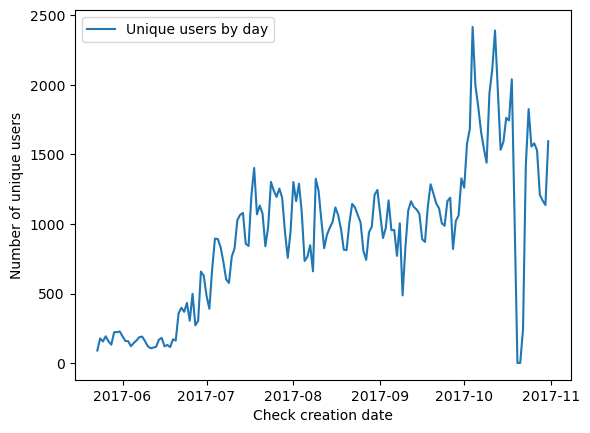

In [120]:
plt.plot(kyc_analysis['doc_created_date'], kyc_analysis['unique_users'],label='Unique users by day')
plt.xlabel('Check creation date')
plt.ylabel('Number of unique users')
plt.legend()
plt.show()

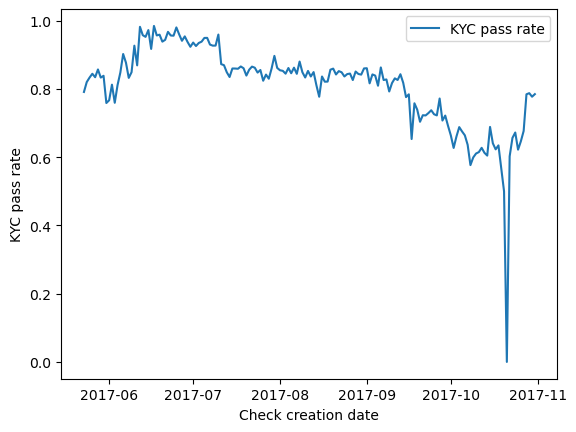

In [119]:
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['pass_rate'],label='KYC pass rate')
plt.legend()
plt.xlabel('Check creation date')
plt.ylabel('KYC pass rate')
plt.show()

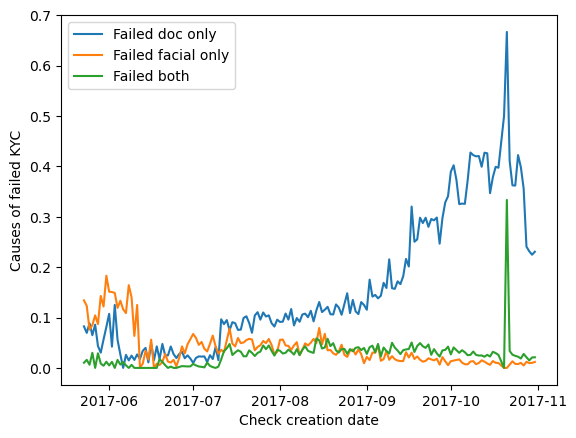

In [125]:
# Visualise drivers of failed KYC 
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['only_doc_check_fail'] /kyc_analysis['total_check_count'] ,label='Failed doc only')
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['only_facial_check_fail'] /kyc_analysis['total_check_count'] ,label='Failed facial only')
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['failed_both_checks'] /kyc_analysis['total_check_count'] ,label='Failed both')

plt.legend()
plt.xlabel('Check creation date')
plt.ylabel('Causes of failed KYC')
plt.show()

In [145]:
# Deep dive into failed doc checks: document check sub-result
doc_check_summary = required_tests['doc_sub_result'].value_counts().reset_index(name='count')
doc_check_summary['percentage'] = doc_check_summary['count'] / doc_check_summary['count'].sum()

In [146]:
doc_check_summary

,doc_sub_result,count,percentage
0,clear,126267,0.757505
1,rejected,24191,0.145127
2,caution,14484,0.086893
3,suspected,1746,0.010475


In [151]:
# Deep dive into failed doc checks: document check sub-result
doc_sub_result = required_tests.groupby('doc_created_date').agg(
    failed_doc_checks = ('doc_check_fail','sum'), 
    rejected_sub_result = ('doc_sub_result', lambda x: (x=='rejected').sum()),
    caution_sub_result = ('doc_sub_result', lambda x: (x=='caution').sum()),
).reset_index()

In [152]:
doc_sub_result

,doc_created_date,failed_doc_checks,rejected_sub_result,caution_sub_result
0,2017-05-23,9,0,9
1,2017-05-24,16,0,16
2,2017-05-25,15,0,15
3,2017-05-26,19,0,19
4,2017-05-27,14,0,14
...,...,...,...,...
156,2017-10-27,720,325,362
157,2017-10-28,367,275,80
158,2017-10-29,332,282,36
159,2017-10-30,319,263,33


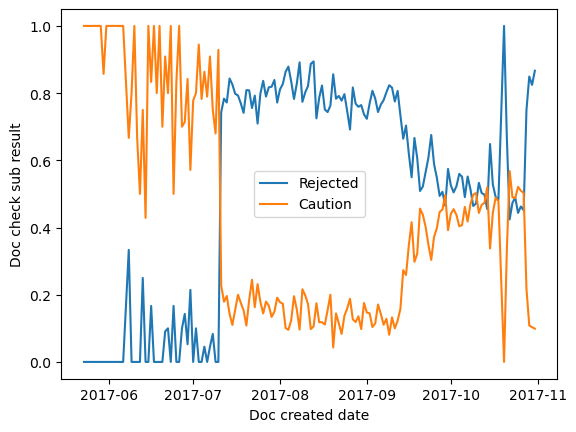

In [155]:
# Doc sub results over time 
plt.plot(doc_sub_result['doc_created_date'],doc_sub_result['rejected_sub_result'] / doc_sub_result['failed_doc_checks'], label='Rejected')
plt.plot(doc_sub_result['doc_created_date'],doc_sub_result['caution_sub_result'] / doc_sub_result['failed_doc_checks'], label='Caution')
plt.legend()
plt.xlabel('Doc created date')
plt.ylabel('Doc check sub result')
plt.show()

In [156]:
# Drivers of rejected doc check sub-result 




### Analysis of users with multiple tries

In [59]:
# Create a new DF for users with multiple tries 
multiple_tries = combined_check_results[combined_check_results['user_id_count']>1]

In [60]:
# Create a copy of the original DF to avoid warnings
multiple_tries = multiple_tries.copy()

# Add new columns to identify unnecessary checks - checks not required due to previous passes - if relevant
multiple_tries.loc[:,'previous_kyc'] = multiple_tries.groupby('user_id')['kyc_pass'].shift(1)

multiple_tries.loc[:,'has_previous_pass'] = multiple_tries.groupby('user_id')['previous_kyc'].cummax()


In [68]:
multiple_tries.loc[:,'necessary_check'] = multiple_tries.apply(lambda row: 1 if row['order']==1 else 
                                                            1 if row['has_previous_pass'] !=1  else
                                                            0, axis=1
                                                           )

In [69]:
#multiple_tries = multiple_tries.drop('neccesassary_check', axis=1)
multiple_tries.head()

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,failed_both_checks,only_doc_check_fail,only_facial_check_fail,user_id_count,kyc_pass,order,previous_kyc,has_previous_pass,neccessary_check,necessary_check
17,17,b20147d91fdf4ac289ddd80c4be9716a,2db4bd5ed28948af858881e5e261bc2d,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,1,0,0,2,1,1,NaN,NaN,1,1
18,18,b20147d91fdf4ac289ddd80c4be9716a,aa906e5f7be04ebca1d79091f5294f58,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,1,0,0,2,1,2,1.0,1.0,0,0
24,24,7e66b2c14ea74d28af5547be220455dd,e3549a16f4054976a7a994f1b268d195,clear,clear,2017-06-20 19:39:10+00:00,clear,clear,clear,clear,...,1,0,0,3,1,1,NaN,NaN,1,1
32,32,80335b5bfe4241b9906b52ca4bac0dc2,863121e980074e3c946c451865627ec3,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,1,0,0,2,1,1,NaN,NaN,1,1
33,33,80335b5bfe4241b9906b52ca4bac0dc2,155bb52483974dc2a8f7beedfc740ec1,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,1,0,0,2,1,2,1.0,1.0,0,0


In [63]:
# Count unique users with unnecessary checks 
users_with_unnecessary_checks = multiple_tries[multiple_tries['neccessary_check']==0]['user_id'].nunique()

In [64]:
# Create a summary table with multiple tries details
summary = {
    'unique_users':[multiple_tries['user_id'].nunique()],
    'total_attemps':[multiple_tries.shape[0]],
    'users_with_unnecessary_checks':[users_with_unnecessary_checks],
    'unnecessary_checks':[multiple_tries[multiple_tries['neccessary_check'] == 0].shape[0]]
}

# Convert to a DF
summary_df = pd.DataFrame(summary)

In [65]:
summary_df

,unique_users,total_attemps,users_with_unnecessary_checks,unnecessary_checks
0,32350,66030,9136,9716


In [ ]:
# Unnecessary checks over time
summary_over_time = multiple_tries.groupby('doc_created_date').agg(
    unique_users = ('user_id','nunique'),
    total_attempts = ('number','count'),
    unnecessary_checks = ('neccessary_check', lambda x: (x==0).sum())
).reset_index()

In [ ]:
summary_over_time['pct_unnecessary_check'] = summary_over_time['unnecessary_checks'] / summary_over_time['total_attempts']

In [ ]:
summary_over_time

In [ ]:
# Number of checks and unnecessary checks
plt.plot(summary_over_time['doc_created_date'], summary_over_time['total_attempts'],label='Total checks')
plt.plot(summary_over_time['doc_created_date'], summary_over_time['unnecessary_checks'], label='Unnecessary checks')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Checks')
plt.show()

In [ ]:
# Percentage of unnecessary checks
summary_over_time.plot(x='doc_created_date',y='pct_unnecessary_check')
plt.show()

### Analysis

In [48]:
# Display doc result over time 
doc_results = combined_check_results.groupby(['doc_created_date','doc_result']).size().unstack(fill_value=0) # Without .unstack(), you'd need extra logic to turn that multi-index Series into a usable table. With .unstack(), it's done in one line.

In [ ]:
doc_results['doc_checks'] = doc_results['clear'] + doc_results['consider']

In [ ]:
doc_results['clear_pct'] = doc_results['clear'] / (doc_results['clear'] + doc_results['consider']) 

In [ ]:
doc_results

In [ ]:
doc_results['doc_checks'].plot(kind='line')
plt.title('Number of checks over time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

In [ ]:
# Make the chart interactive

# Check clear contribution over time
doc_results['clear_pct'].plot(kind='line')
plt.title('Daily clear percentage of doc checks')
plt.xlabel('Doc check date')
plt.ylabel('Clear %')

#plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.show()

In [ ]:
# Entries where both facial and document checks are clear 
combined_check_results['kyc_pass'] = combined_check_results.apply(lambda row: 1 if row['facial_result']=='clear' and row['doc_result']=='clear' else 0,axis=1)

In [ ]:
# Calcualte if the user passed at least once
user_pass_rate = combined_check_results.groupby('user_id')['kyc_pass'].max()

In [ ]:
user_pass_rate

In [ ]:
overall_pass_rate = user_pass_rate.mean()

In [ ]:
overall_pass_rate

In [ ]:
# Combine data and user level data
user_pass_rate = combined_check_results.groupby(['user_id','doc_created_date'])['kyc_pass'].max().reset_index()

In [ ]:
user_pass_rate

In [ ]:
date_pass_rate = user_pass_rate.groupby('doc_created_date')['kyc_pass'].mean().reset_index()

In [ ]:
daily_tries = user_pass_rate.groupby('doc_created_date')['user_id'].nunique().reset_index()

In [ ]:
daily_tries.rename(columns={'user_id':'unique_tries'},inplace=True)
daily_tries

In [ ]:
# Idea: Post two charts next to each other: number of unique users per day and kyc pass rate 

In [ ]:
date_pass_rate.plot(x='doc_created_date', y='kyc_pass',kind='line')
plt.show()

In [ ]:
combined_check_results

In [ ]:
# see if fail is driven by facial or doc check results
combined_check_results['doc_fail'] = combined_check_results['doc_result'].apply(lambda x: 1 if x != 'clear' else 0)

In [ ]:
combined_check_results['facial_fail'] = combined_check_results['facial_result'].map(lambda x: 1 if x !='clear' else 0)

In [ ]:
combined_check_results

In [ ]:
# Users with multiple tries
combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')

In [ ]:
combined_check_results

In [ ]:
# Multiple tries and clear both 
multiple_tries = combined_check_results[combined_check_results['user_id_count']>1]

In [ ]:
# Add order to show sequence of tests at user level
multiple_tries.loc[:,'order'] = multiple_tries.sort_values(by=['user_id','number']).groupby('user_id').cumcount()+1

In [ ]:
multiple_tries

In [ ]:
# Create a summary table with multiple tries details
summary = {
    'unique_users':[multiple_tries['user_id'].nunique()],
    'total_attemps':[multiple_tries.shape[0]],
}

# Convert to a DF
summary_df = pd.DataFrame(summary)

In [ ]:
summary_df

In [ ]:
first_attempt_passed = multiple_tries[(multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==1)]

In [ ]:
fa_test = first_attempt_passed.agg({
   'user_id':'nunique',
    'user_id_count':'sum'
})

# convert to DF
first_attempt_df = fa_test.to_frame().T

In [ ]:
first_attempt_df

In [ ]:
# Users who passed kyc on second try but had 3 sumbmissions
second_attempt_passed = multiple_tries[(~multiple_tries['user_id'].isin(first_attempt_passed['user_id'])) & (multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==2) & (multiple_tries['user_id_count']==3)]

In [ ]:
second_attempt_passed

In [ ]:
second_attempt_df ={
    'unique_users': [second_attempt_passed['user_id'].nunique()],
    'unneccessary_attempts' : [second_attempt_passed['user_id'].nunique()]
}

In [ ]:
# Prevent users to submit new test if they passed one already 

In [ ]:
# Add results to summary DF
summary_df['users_with_unneccessary_checks'] = first_attempt_df['user_id'] + second_attempt_df['unique_users']
summary_df['unneccessary_attempts'] = first_attempt_df['user_id_count'] - first_attempt_df['user_id'] + second_attempt_df['unneccessary_attempts']

In [ ]:
summary_df

In [ ]:
# Percentage of users with unneccessary checks
print(summary_df['users_with_unneccessary_checks'] / summary_df['unique_users'])

In [ ]:
#multiple_tries.to_csv('test.csv')
#multiple_tries[multiple_tries['user_id_count']==5].sort_values(by=['user_id','number'])

### Analysis of failure issues

In [ ]:
combined_check_results.loc[168513]

In [ ]:
combined_check_results['visual_authenticity_result_x'] = combined_check_results['visual_authenticity_result_x'].str.strip()
combined_check_results['visual_authenticity_result_y'] = combined_check_results['visual_authenticity_result_y'].str.strip()

In [ ]:
# Check if visual authenticity columns are the same
(combined_check_results['visual_authenticity_result_x'] == combined_check_results['visual_authenticity_result_y']).all()

In [ ]:
combined_check_results['visual_authenticity_result_x'] != combined_check_results['visual_authenticity_result_y']

In [ ]:
test = combined_check_results[['visual_authenticity_result_x','visual_authenticity_result_y']]

In [ ]:
(test['visual_authenticity_result_x'] == test['visual_authenticity_result_y'])

In [ ]:
test['visual_authenticity_result_x'].equals(test['visual_authenticity_result_y'])

In [ ]:
test[test['visual_authenticity_result_x'] != test['visual_authenticity_result_y']]

In [ ]:
test['visual_authenticity_result_x'].equals(test['visual_authenticity_result_y'])

In [ ]:
np.where(
    (test['visual_authenticity_result_x'] == test['visual_authenticity_result_y']) | (test['visual_authenticity_result_x'].isna() & test['visual_authenticity_result_y'].isna()),
    True,
    False
)

In [ ]:
# See where columns differ
test['visual_authenticity_result_x'].compare(test['visual_authenticity_result_y'], keep_equal=True)

In [ ]:
combined_check_results.head()

In [ ]:
# Check if properties columns match exactly 
matches = (combined_check_results['properties_x'] == combined_check_results['properties_y']).sum()
print(matches)